In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [3]:
# Dataset escolhido: Wine Quality (red wine)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dimensões do dataset:", df.shape)
display(df.head())

Dimensões do dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Informações gerais
print("Informações das colunas:")
display(df.info())

print("\nValores nulos por coluna:")
display(df.isnull().sum())

print("\nEstatísticas descritivas:")
display(df.describe())

Informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None


Valores nulos por coluna:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Estatísticas descritivas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# regressão, prever a nota original 'quality'
# classificação, alvo binário:
# 1 = vinho bom (quality >= 7)
# 0 = vinho comum/abaixo do corte (quality < 7)

df["bom_vinho"] = (df["quality"] >= 7).astype(int)

print("Distribuição da variável de classificação:")
display(df["bom_vinho"].value_counts())

# Features (atributos preditores)
X = df.drop(columns=["quality", "bom_vinho"])

# Alvos
y_reg = df["quality"]
y_clf = df["bom_vinho"]

print("Variáveis preditoras:")
display(X.columns.tolist())

Distribuição da variável de classificação:


,count
bom_vinho,
0,1382
1,217


Variáveis preditoras:


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [6]:
# Regressão
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Classificação (com estratificação para preservar a proporção das classes)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print("Regressão -> treino:", X_train_reg.shape, "| teste:", X_test_reg.shape)
print("Classificação -> treino:", X_train_clf.shape, "| teste:", X_test_clf.shape)

Regressão -> treino: (1279, 11) | teste: (320, 11)
Classificação -> treino: (1279, 11) | teste: (320, 11)


In [7]:
# Préprocessamento:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)])

In [8]:
# Modelo 1: KNN
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))])

# Modelo 2: Regressão Logística
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))])

knn_model.fit(X_train_clf, y_train_clf)
logreg_model.fit(X_train_clf, y_train_clf)

print("Modelos de classificação treinados com sucesso.")

Modelos de classificação treinados com sucesso.


In [ ]:
def avaliar_classificacao(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"===== {nome_modelo} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nMatriz de confusão:")
    print(cm)
    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-" * 60)

    return {
        "Modelo": nome_modelo,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

resultado_knn = avaliar_classificacao("KNN", knn_model, X_test_clf, y_test_clf)
resultado_logreg = avaliar_classificacao("Regressão Logística", logreg_model, X_test_clf, y_test_clf)

resultados_classificacao = pd.DataFrame([resultado_knn, resultado_logreg])
display(resultados_classificacao.sort_values(by="F1-score", ascending=False))

===== KNN =====
Accuracy : 0.8938
Precision: 0.6667
Recall   : 0.4186
F1-score : 0.5143

Matriz de confusão:
[[268   9]
 [ 25  18]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.67      0.42      0.51        43

    accuracy                           0.89       320
   macro avg       0.79      0.69      0.73       320
weighted avg       0.88      0.89      0.88       320

------------------------------------------------------------
===== Regressão Logística =====
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848

Matriz de confusão:
[[270   7]
 [ 27  16]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
we

,Modelo,Accuracy,Precision,Recall,F1-score
0,KNN,0.89375,0.666667,0.418605,0.514286
1,Regressão Logística,0.89375,0.695652,0.372093,0.484848


In [ ]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train_reg, y_train_reg)

print("Modelo de regressão linear treinado com sucesso.")

Modelo de regressão linear treinado com sucesso.


In [ ]:
y_pred_reg = linear_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("===== Regressão Linear =====")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

resultados_regressao = pd.DataFrame([{
    "Modelo": "Regressão Linear",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}])

display(resultados_regressao)

===== Regressão Linear =====
MAE : 0.5035
MSE : 0.3900
RMSE: 0.6245
R²  : 0.4032


,Modelo,MAE,MSE,RMSE,R2
0,Regressão Linear,0.50353,0.390025,0.62452,0.40318


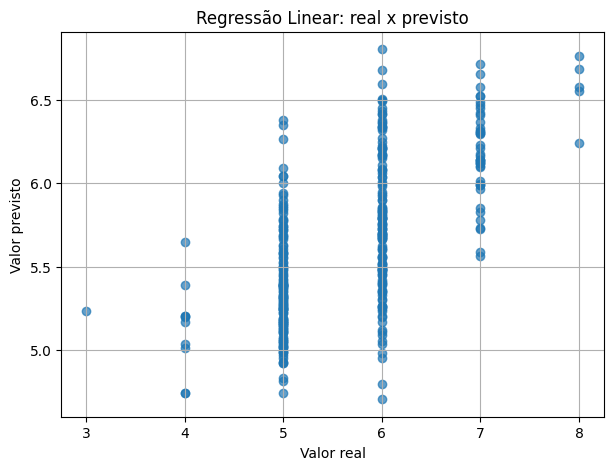

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Regressão Linear: real x previsto")
plt.grid(True)
plt.show()